In [22]:
# Import Necessary Libraries;
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn
import torch

In [3]:
# Upload data;
df = pd.read_csv("seismic_activity_svm.csv")

In [4]:
# Information about the dataset;
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
None


In [7]:
print(df.describe())

       underground_wave_energy  vibration_axis_variation  \
count               400.000000              4.000000e+02   
mean                  0.000000              8.881784e-18   
std                   7.719350              1.751650e+00   
min                  -9.999954             -3.000000e+00   
25%                  -6.134779             -1.500000e+00   
50%                   0.000000              0.000000e+00   
75%                   6.134779              1.500000e+00   
max                   9.999954              3.000000e+00   

       seismic_event_detected  
count              400.000000  
mean                 0.500000  
std                  0.500626  
min                  0.000000  
25%                  0.000000  
50%                  0.500000  
75%                  1.000000  
max                  1.000000  


In [6]:
print(df.nunique())

underground_wave_energy     206
vibration_axis_variation    144
seismic_event_detected        2
dtype: int64


Text(0.5, 1.0, 'Seismic Activity')

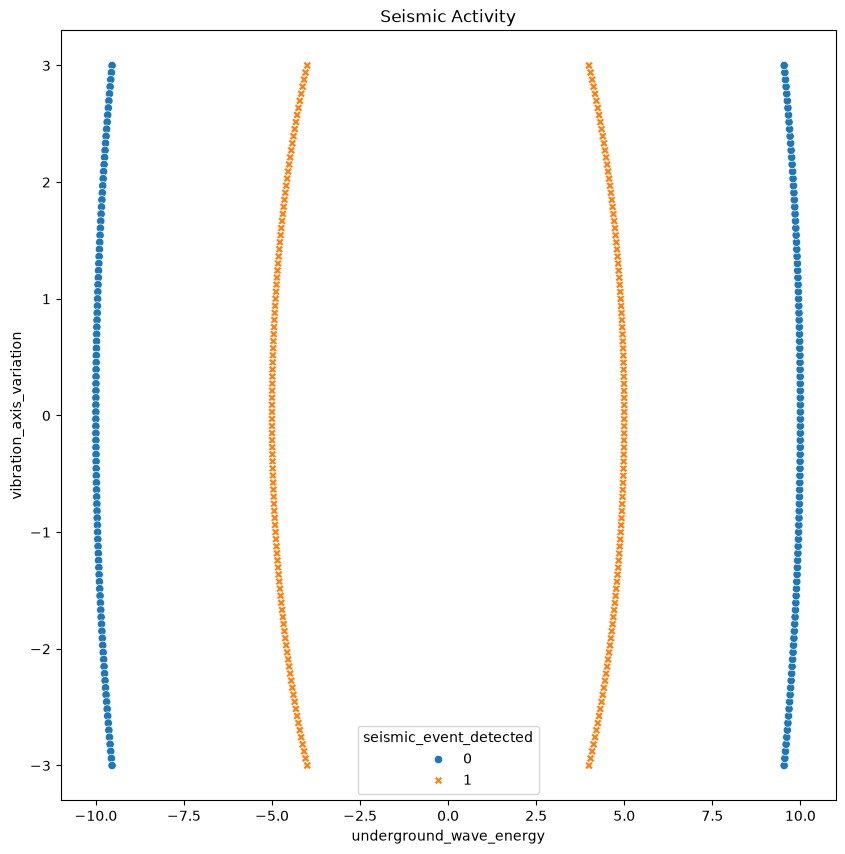

In [13]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x=df['underground_wave_energy'], y=df['vibration_axis_variation'], hue=df['seismic_event_detected'], style=df['seismic_event_detected'])
plt.title('Seismic Activity')




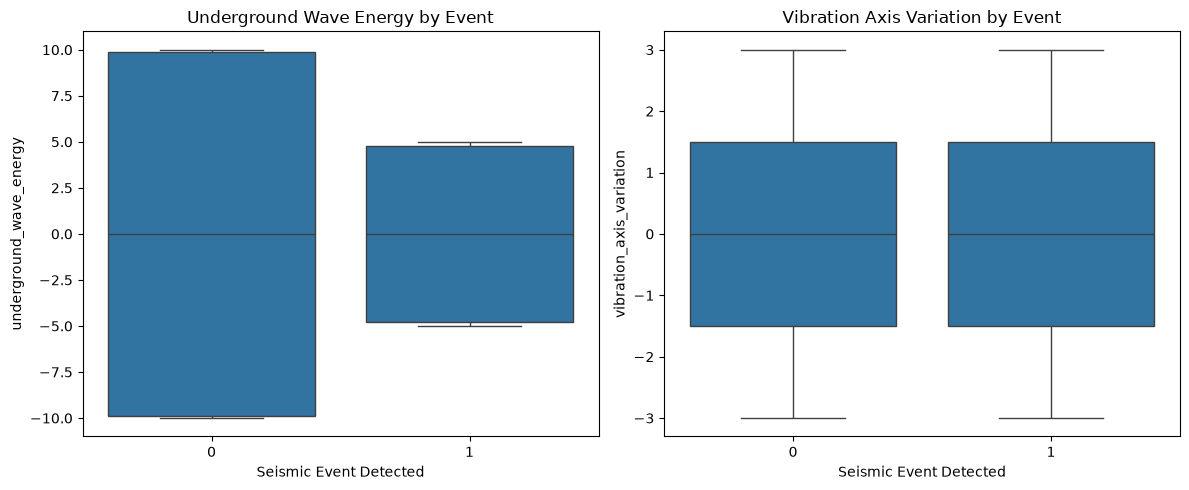

In [15]:
# Feature vs target relationship;
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='seismic_event_detected', y='underground_wave_energy', data=df, ax=axes[0])
axes[0].set_title('Underground Wave Energy by Event')
axes[0].set_xlabel('Seismic Event Detected')

sns.boxplot(x='seismic_event_detected', y='vibration_axis_variation', data=df, ax=axes[1])
axes[1].set_title('Vibration Axis Variation by Event')
axes[1].set_xlabel('Seismic Event Detected')

plt.tight_layout()
plt.show()

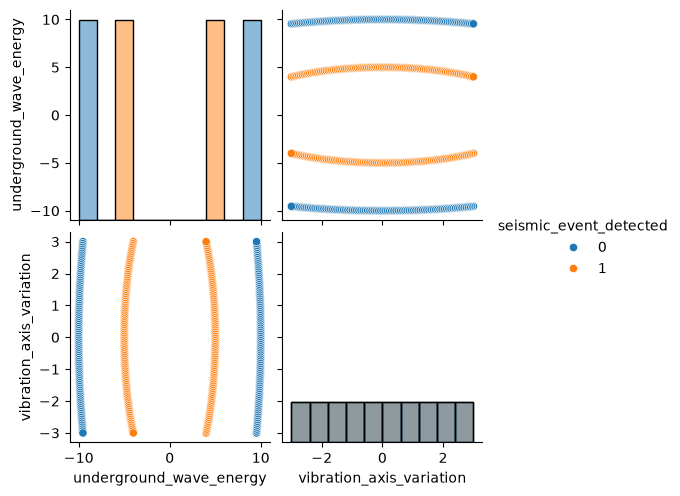

In [16]:
# Pairplot: all feature combinations + target;
sns.pairplot(df, hue='seismic_event_detected', diag_kind='hist')
plt.show()

In [35]:
X = df[['underground_wave_energy','vibration_axis_variation']].values
y = df['seismic_event_detected'].values

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)



(400, 2) (400,)
(320, 2) (320,)
(80, 2) (80,)


In [36]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(y_test.ndim, y_train.ndim)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])
2 2


In [46]:
class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10,1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1 = NonLinearModel()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [47]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [49]:
torch.manual_seed(42)
epochs = []

for epoch in range(500):
    model_1.train()
    y_logits = model_1(X_train)
    y_preds = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test)
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_preds)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss.item()}, Accuracy: {acc}, Test Loss: {test_loss.item()}, Test Accuracy: {test_acc}")


Epoch: 0, Loss: 0.5259692072868347, Accuracy: 77.1875, Test Loss: 0.5177497267723083, Test Accuracy: 77.5
Epoch: 10, Loss: 0.5083373785018921, Accuracy: 80.625, Test Loss: 0.49797019362449646, Test Accuracy: 82.5
Epoch: 20, Loss: 0.4893997311592102, Accuracy: 83.125, Test Loss: 0.4792848229408264, Test Accuracy: 83.75
Epoch: 30, Loss: 0.46891552209854126, Accuracy: 85.3125, Test Loss: 0.4600309729576111, Test Accuracy: 90.0
Epoch: 40, Loss: 0.4396637976169586, Accuracy: 100.0, Test Loss: 0.4285210072994232, Test Accuracy: 100.0
Epoch: 50, Loss: 0.40778565406799316, Accuracy: 100.0, Test Loss: 0.3987943232059479, Test Accuracy: 100.0
Epoch: 60, Loss: 0.3791818618774414, Accuracy: 100.0, Test Loss: 0.3679294288158417, Test Accuracy: 100.0
Epoch: 70, Loss: 0.34654802083969116, Accuracy: 100.0, Test Loss: 0.33181387186050415, Test Accuracy: 100.0
Epoch: 80, Loss: 0.31421715021133423, Accuracy: 100.0, Test Loss: 0.30055731534957886, Test Accuracy: 100.0
Epoch: 90, Loss: 0.28788089752197266,

In [52]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid describe
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Change of the grib to tensor for model
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Prediction
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary plot (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Real points
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

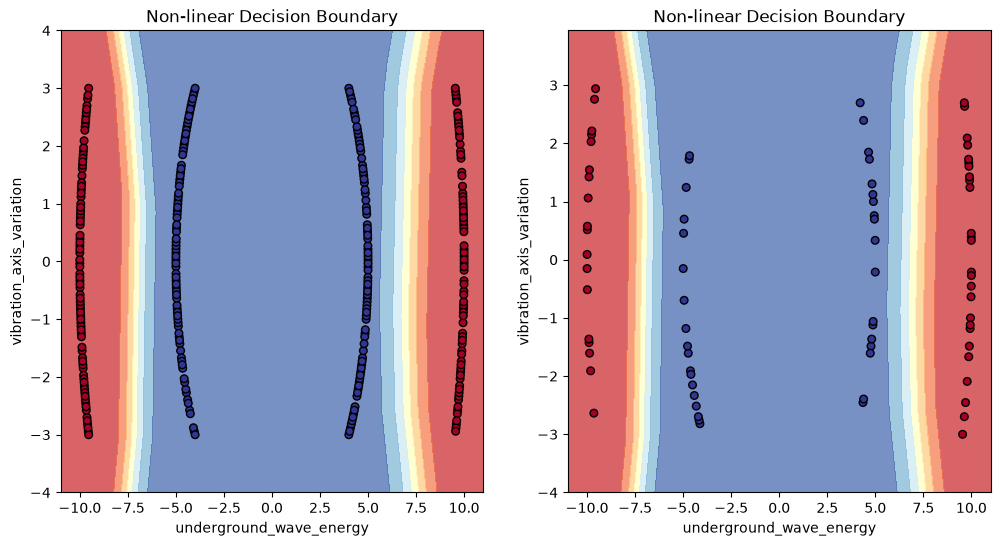

In [54]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model_1, X_test, y_test)

plt.show()